# Cuaderno 3: Factorización LU/PLU

En este cuaderno trabajamos, de forma **conceptual**, la factorización de una matriz cuadrada como producto de una matriz triangular inferior y una triangular superior:

1. **Factorización LU**: qué es, cuándo existe y cómo se obtiene a partir de la eliminación de Gauss (sin intercambios de fila).
2. **Factorización PLU**: qué hacer cuando se necesitan intercambios de fila (pivoteo), y por qué siempre existe para una matriz invertible.
3. **Uso de LU/PLU**: cómo resolver $Ax=b$ de forma eficiente mediante sustitución hacia adelante y hacia atrás.

Todo el análisis se hace registrando los **multiplicadores** de la eliminación de Gauss, que son exactamente las entradas de $L$.

In [1]:
from sympy import Matrix, Rational, symbols, eye, zeros, init_printing
init_printing()  # para que las matrices se vean bonitas

## 1. ¿Qué es la factorización LU?

Dada una matriz **cuadrada** $A$ de tamaño $n\times n$, una **factorización LU** de $A$ es una escritura de la forma

$$A = LU$$

donde:

- $L$ es **triangular inferior** con **unos en la diagonal** (matriz unitriangular inferior).
- $U$ es **triangular superior**.

Puntos clave:

- $U$ es justamente la matriz que resulta de llevar $A$ a forma escalonada usando **solo** la operación "sumar un múltiplo de una fila a otra" (sin intercambios de fila).
- $L$ guarda la información de **cómo se hizo** esa eliminación: cada entrada $\ell_{ij}$ (con $i>j$) es el **multiplicador** usado para eliminar la entrada $(i,j)$ usando el pivote de la fila $j$.
- Por eso decimos que LU es una forma de **empaquetar la eliminación de Gauss**: en vez de solo guardar el resultado final $U$, guardamos también el "historial" de la eliminación en $L$.

### ¿Para qué sirve?

Si tenemos $A = LU$ y queremos resolver $Ax = b$, en vez de reducir $[A\mid b]$ desde cero, hacemos:

$$Ax = b \iff LUx = b \iff \begin{cases} Ly = b & \text{(sustitución hacia adelante, } L \text{ es triangular inferior)}\\ Ux = y & \text{(sustitución hacia atrás, } U \text{ es triangular superior)}\end{cases}$$

Ambos sistemas triangulares se resuelven de forma directa (sin más eliminación). Esto es muy útil cuando hay que resolver $Ax=b$ para **muchos vectores $b$ distintos** con la **misma** matriz $A$: la factorización $A=LU$ se calcula **una sola vez** y luego cada sistema nuevo cuesta solo dos sustituciones.

## 2. ¿Cuándo existe la factorización LU (sin intercambios de fila)?

La factorización LU (sin pivoteo) existe si y solo si la eliminación de Gauss se puede completar **sin necesitar intercambiar filas**, es decir, si en cada paso el pivote que aparece de forma natural es distinto de cero.

Una condición equivalente y más formal: $A$ tiene factorización LU si todos sus **menores principales** (los determinantes de las submatrices $A_{1:k,\,1:k}$ para $k=1,\dots,n-1$) son distintos de cero.

Si en algún paso el pivote natural es $0$ pero existe una fila debajo con una entrada no nula en esa columna, **sí** existe solución, pero se necesita un intercambio de fila: ahí es donde aparece la factorización **PLU** (sección 4).

## 3. Construcción paso a paso de LU

Vamos a factorizar

$$A = \begin{bmatrix} 2 & 1 & 1 \\ 4 & 3 & 3 \\ 8 & 7 & 9 \end{bmatrix}$$

usando eliminación de Gauss y guardando los multiplicadores en $L$.

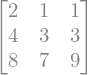

In [6]:
A = Matrix([
    [2, 1, 1],
    [4, 3, 3],
    [8, 7, 9]
])
U = A.copy()   # aqui iremos aplicando la eliminacion
L = eye(3)     # aqui guardamos los multiplicadores
U

### Paso 1: eliminar la columna 1 debajo del pivote $u_{11}=2$

Multiplicadores: $\ell_{21} = \dfrac{4}{2} = 2$, $\ell_{31} = \dfrac{8}{2} = 4$.

$R_2 \to R_2 - \ell_{21} R_1$, $R_3 \to R_3 - \ell_{31} R_1$

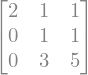

In [7]:
l21 = U[1, 0] / U[0, 0]
l31 = U[2, 0] / U[0, 0]

U[1, :] = U[1, :] - l21 * U[0, :]
U[2, :] = U[2, :] - l31 * U[0, :]

L[1, 0] = l21
L[2, 0] = l31
U

### Paso 2: eliminar la columna 2 debajo del pivote $u_{22}$

Multiplicador: $\ell_{32} = \dfrac{u_{32}}{u_{22}}$.

$R_3 \to R_3 - \ell_{32} R_2$

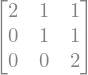

In [8]:
l32 = U[2, 1] / U[1, 1]

U[2, :] = U[2, :] - l32 * U[1, :]

L[2, 1] = l32
U

$U$ ya es triangular superior (todos los pivotes fueron distintos de cero, no hubo que intercambiar filas). $L$ quedó así:

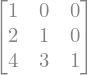

In [5]:
L

### Verificación: $LU$ debe dar $A$

In [13]:
L*U == A

True

Comparemos con la factorización que da `sympy` directamente (su método interno puede aplicar pivoteo aunque no sea estrictamente necesario, por eso comparamos $L$, $U$ y la permutación):

In [ ]:
L_sp, U_sp, perm = A.LUdecomposition()
L_sp, U_sp, perm  # perm vacio significa que no hubo intercambios de fila

## 4. ¿Cuándo se necesita PLU (con intercambios de fila)?

Si en algún paso el pivote natural es $0$ (o, por estabilidad numérica, muy pequeño), se necesita **intercambiar filas** antes de eliminar. Ese intercambio se registra en una **matriz de permutación** $P$ (una matriz identidad con las filas reordenadas).

En ese caso ya no obtenemos $A=LU$ directamente, sino

$$PA = LU$$

es decir: **reordenando primero las filas de $A$ según $P$**, sí es posible eliminar sin más intercambios.

**Dato clave:** toda matriz cuadrada **invertible** admite una factorización PLU (aunque no admita LU directo). Por eso PLU es la versión "robusta" de la factorización, la que en la práctica usan las librerías numéricas.

### Ejemplo: una matriz que necesita intercambio de fila

$$B = \begin{bmatrix} 0 & 1 & 1 \\ 2 & 1 & 1 \\ 4 & 3 & 3 \end{bmatrix}$$

El pivote natural $b_{11}=0$, así que no se puede eliminar la columna 1 sin antes intercambiar filas.

In [ ]:
B = Matrix([
    [0, 1, 1],
    [2, 1, 1],
    [4, 3, 3]
])
B

Intercambiamos $R_1 \leftrightarrow R_2$ (esto define $P$) y luego eliminamos con normalidad:

In [ ]:
P = eye(3)
P[0, :], P[1, :] = P[1, :], P[0, :]  # misma permutacion que aplicamos a B

PB = P * B
PB

In [ ]:
Ub = PB.copy()
Lb = eye(3)

l21 = Ub[1, 0] / Ub[0, 0]
l31 = Ub[2, 0] / Ub[0, 0]
Ub[1, :] = Ub[1, :] - l21 * Ub[0, :]
Ub[2, :] = Ub[2, :] - l31 * Ub[0, :]
Lb[1, 0], Lb[2, 0] = l21, l31

l32 = Ub[2, 1] / Ub[1, 1]
Ub[2, :] = Ub[2, :] - l32 * Ub[1, :]
Lb[2, 1] = l32

Ub

### Verificación: debe cumplirse $PB = L_bU_b$ (equivalentemente $B = P^{-1}L_bU_b = P^{T}L_bU_b$, pues $P$ es ortogonal)

In [ ]:
P * B == Lb * Ub, P.T * Lb * Ub == B

In [ ]:
L_sp, U_sp, perm = B.LUdecomposition()
L_sp, U_sp, perm  # perm indica los intercambios de fila que hizo sympy

## 5. Teorema (versión LU/PLU)

Para una matriz cuadrada $A$ de $n\times n$:

- $A$ admite factorización $A=LU$ (sin intercambios) $\iff$ la eliminación de Gauss se completa sin pivotes nulos $\iff$ todos los menores principales de $A$ son distintos de cero.
- Toda matriz **invertible** admite factorización $PA=LU$ para alguna matriz de permutación $P$.
- Si $A$ es invertible, $U$ tiene todos sus elementos diagonales distintos de cero, y $\det(A) = \pm\det(U) = \pm\prod_i u_{ii}$ (el signo depende de la paridad de la permutación $P$).
- Si $A$ es **singular** (no invertible), en algún paso aparecerá una columna sin ningún pivote posible (todas las entradas candidatas son cero), y la eliminación produce una fila de ceros en $U$: por eso $\det(U)=0$.

## 6. Usar LU para resolver $Ax=b$

Con la factorización $A=LU$ de la sección 3, resolvamos $Ax=b$ para $b=\begin{bmatrix}5\\17\\36\end{bmatrix}$ mediante sustitución hacia adelante y hacia atrás.

In [ ]:
b = Matrix([5, 17, 36])

# Paso 1: Ly = b (sustitucion hacia adelante, L triangular inferior con unos en la diagonal)
y = L.solve(b)
y

In [ ]:
# Paso 2: Ux = y (sustitucion hacia atras, U triangular superior)
x = U.solve(y)
x

In [ ]:
# Comprobacion directa
A * x == b

## Resumen

- $A = LU$ empaqueta la eliminación de Gauss: $U$ es el resultado final y $L$ guarda los multiplicadores usados en cada paso.
- LU (sin pivoteo) existe cuando la eliminación no requiere intercambiar filas (menores principales distintos de cero).
- Cuando se requieren intercambios, se obtiene $PA=LU$; toda matriz invertible admite esta forma.
- La utilidad principal de LU/PLU es resolver $Ax=b$ para varios $b$ con la misma $A$ mediante dos sustituciones triangulares (adelante con $L$, atrás con $U$), evitando repetir la eliminación completa cada vez.

## Ejercicios propuestos

### Ejercicio 1

Calcula, a mano y luego con `sympy`, la factorización LU de

$$A = \begin{bmatrix} 4 & 3 \\ 6 & 3 \end{bmatrix}$$

siguiendo el procedimiento de la sección 3 (registrando el multiplicador en $L$), y verifica que $LU=A$.

In [ ]:
# Ejercicio 1
A = Matrix([[4, 3], [6, 3]])


### Ejercicio 2

La matriz

$$C = \begin{bmatrix} 0 & 2 & 1 \\ 0 & 4 & 3 \\ 3 & 1 & 1 \end{bmatrix}$$

no admite LU directo. Explica por qué (mira el pivote natural de la columna 1 y también el de la columna 2 después del primer intercambio), determina la permutación $P$ necesaria y halla $L$ y $U$ tales que $PC=LU$.

In [ ]:
# Ejercicio 2
C = Matrix([[0, 2, 1], [0, 4, 3], [3, 1, 1]])


### Ejercicio 3

Usando la factorización $A=LU$ que obtuviste en el Ejercicio 1, resuelve $Ax=b$ para $b=\begin{bmatrix}18\\21\end{bmatrix}$ mediante sustitución hacia adelante ($Ly=b$) y hacia atrás ($Ux=y$), sin usar `A.solve` directamente sobre $A$.

In [ ]:
# Ejercicio 3
b = Matrix([18, 21])


### Ejercicio 4: LU y determinante de una matriz singular

Considera

$$D = \begin{bmatrix} 1 & 2 & 3 \\ 2 & 4 & 7 \\ 1 & 2 & 3 \end{bmatrix}$$

Intenta construir $U$ mediante eliminación de Gauss. ¿Qué pasa en el último paso? Relaciona lo que observas con el hecho de que $D$ es singular y con la fórmula $\det(A)=\prod_i u_{ii}$ (hasta signo).

In [ ]:
# Ejercicio 4
D = Matrix([[1, 2, 3], [2, 4, 7], [1, 2, 3]])


## Preguntas conceptuales

Para cada pregunta, responde primero razonando (sin calcular), y luego comprueba tu respuesta construyendo un ejemplo numérico con `sympy`. Si tu conjetura falla, ajusta el enunciado con la condición adicional que la hace verdadera.

### Pregunta 1: unicidad de LU

Si $A$ admite factorización $A=LU$ con $L$ unitriangular inferior (unos en la diagonal), ¿es esa factorización **única**? ¿Qué pasaría si no exigiéramos que la diagonal de $L$ fuera de unos?

In [ ]:
# Pregunta 1: compara A.LUdecomposition() con la LU que calculaste a mano


### Pregunta 2: LU de una matriz triangular

Si $A$ ya es triangular superior, ¿cuáles son $L$ y $U$ en su factorización LU? ¿Y si $A$ es triangular inferior con unos en la diagonal?

In [ ]:
# Pregunta 2: prueba con una matriz triangular superior y observa L y U


### Pregunta 3: costo de resolver varios sistemas

Si necesitas resolver $Ax=b_1$, $Ax=b_2$, ..., $Ax=b_5$ con la misma matriz $A$, ¿por qué conviene calcular $A=LU$ una sola vez en vez de reducir $[A\mid b_i]$ cada vez? Verifica con `sympy` que usar $L$ y $U$ ya calculados da el mismo resultado que resolver cada sistema desde cero.

In [ ]:
# Pregunta 3: usa la A y la L, U de la seccion 3 con varios b distintos
